In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import numpy as np
import random

from tqdm import tqdm
from IPython.display import clear_output

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

from dm_control import suite

In [2]:
NUM_TRAJECTORIES = 10000
TRAJECTORY_LEN = 1000

In [3]:
STATE_DIM = 27
ACTION_DIM = 6
AUX_DIM = 3
env = suite.load(
    domain_name='walker',
    task_name='run',
    environment_kwargs=dict(flat_observation=True)
)
dataset = np.load('datasets/walker_rnd.npy', allow_pickle=True).item()
aux = np.load('datasets/aux_walker.npy')
dataset['observations'] = np.concatenate((dataset['observations'], aux.reshape(10000, 1000, 3)), axis=-1)

In [20]:
# env.reset()

# for i in range(1000):
#     with env.physics.reset_context():
#         env.physics.set_state(dataset['physics'][50, i])
    
#     horizontal_velocity = env.physics.horizontal_velocity()
#     torso_upright = env.physics.torso_upright()
#     torso_height = env.physics.torso_height()
#     aux_i = np.array([horizontal_velocity, torso_upright, torso_height])
#     print(aux_i)
#     print(dataset['observations'][50, i, s24:])
#     print()
#     # break

In [29]:
class VelocityRewardFunctionWalker:
    def __init__(self):
        pass    

    def _sigmoids(self, x, value_at_1, sigmoid):
        if sigmoid == 'gaussian':
            scale = np.sqrt(-2 * np.log(value_at_1))
            return np.exp(-0.5 * (x*scale)**2)

        elif sigmoid == 'linear':
            scale = 1-value_at_1
            scaled_x = x*scale
            return np.where(abs(scaled_x) < 1, 1 - scaled_x, 0.0)
    
    def tolerance(self, x, lower, upper, margin=0.0, sigmoid='gaussian', value_at_margin=0.1):
        in_bounds = np.logical_and(lower <= x, x <= upper)
        d = np.where(x < lower, lower - x, x - upper) / margin
        value = np.where(in_bounds, 1.0, self._sigmoids(d, value_at_margin, sigmoid))
        return torch.tensor(value)
    
    def compute_reward(self, states, params):
        
        if isinstance(params, int) or isinstance(params, float):
            params = torch.full((*states.shape[:-1], 1), fill_value=params)
        
        assert len(states.shape) == len(params.shape), states.shape # (batch_size, obs_dim) OR (batch_size, num_pairs, obs_dim)

        _STAND_HEIGHT = 1.2
        horizontal_velocity = states[..., 24:25]
        torso_upright = states[..., 25:26]
        torso_height = states[..., 26:27]
        standing = self.tolerance(torso_height, lower=_STAND_HEIGHT, upper=float('inf'), margin=_STAND_HEIGHT/2)
        upright = (1 + torso_upright) / 2
        stand_reward = (3*standing + upright) / 4
        move_reward = self.tolerance(horizontal_velocity,
                                        lower=params,
                                        upper=float('inf'),
                                        margin=params/2,
                                        value_at_margin=0.5,
                                        sigmoid='linear')
        # move_reward[params == 0] = stand_reward[params == 0]
        rew = stand_reward * (5*move_reward + 1) / 6
        # rew = (5*move_reward + 1) / 6
        
        return torch.tensor(rew[..., 0])



velocity_reward_function = VelocityRewardFunctionWalker()

def reward_function(state):
    return velocity_reward_function.compute_reward(state, 8)

In [30]:
dataset_trajectories = torch.tensor(dataset['observations']).float()
dataset_trajectories = dataset_trajectories
# dataset_trajectories = torch.concatenate((dataset_trajectories[..., [0, 1]], dataset_trajectories[..., [15, 16]]), dim=-1)

dataset_actions = torch.tensor(dataset['actions']).float()
dataset_terminals = torch.tensor(dataset['terminals']).float()
dataset_timeouts = torch.zeros(NUM_TRAJECTORIES, TRAJECTORY_LEN).bool()
dataset_timeouts[:, -1] = True

dataset_goals = torch.tensor(dataset['infos/goal']).float()



dataset_trajectories = dataset_trajectories.reshape(-1, TRAJECTORY_LEN, STATE_DIM)
dataset_actions = dataset_actions.reshape(-1, TRAJECTORY_LEN, ACTION_DIM)
dataset_terminals = dataset_terminals
dataset_timeouts = dataset_timeouts.reshape(-1, TRAJECTORY_LEN)

dataset_rewards = reward_function(dataset_trajectories)

num_trajectories, len_trajectory, obs_dim = dataset_trajectories.shape

/tmp/ipykernel_19852/1924726322.py:45: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(rew[..., 0])


# IQL:

In [111]:
import torch
import torch.nn as nn

class MLP(nn.Module):
    """Generic MLP with Mish activation and LayerNorm."""
    def __init__(self, input_dim, hidden_dims, output_dim):
        super().__init__()
        layers = []
        prev_dim = input_dim

        # Add hidden layers with Mish activation and LayerNorm
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.Mish())
            # layers.append(nn.LayerNorm(hidden_dim))
            prev_dim = hidden_dim  # Update input size for next layer
        
        # Final output layer
        layers.append(nn.Linear(prev_dim, output_dim))

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


class ValueCritic(nn.Module):
    def __init__(self, obs_dim, hidden_dims):
        super().__init__()
        self.model = MLP(obs_dim, hidden_dims, output_dim=1)

    def forward(self, x):
        return self.model(x)


class Critic(nn.Module):
    def __init__(self, obs_dim, action_dim, hidden_dims):
        super().__init__()

        self.model1 = MLP(obs_dim + action_dim, hidden_dims, output_dim=1)
        self.model2 = MLP(obs_dim + action_dim, hidden_dims, output_dim=1)

    def forward(self, x, action):
        x = torch.cat((x, action), dim=-1)
        
        q1 = self.model1(x)
        q2 = self.model2(x)
        
        return q1, q2



class Actor(nn.Module):
    def __init__(self, input_dim, action_dim, hidden_dims, init_std=0.0):
        super().__init__()
        self.model = MLP(input_dim, hidden_dims, output_dim=action_dim)  # MLP only predicts mean
        
        # Learnable log standard deviation (initialized to `init_std`)
        self.log_std = nn.Parameter(torch.ones(action_dim) * init_std)

    def forward(self, x, temperature=1.0):
        mean = self.model(x)  # Predict action mean

        log_std = torch.clip(self.log_std, -20, 2)
        mean = torch.clip(mean, -5, 5)

        return torch.distributions.Normal(
            mean, 
            torch.exp(log_std)*temperature
        )


from torch.optim.lr_scheduler import CosineAnnealingLR
import copy


class IQL(nn.Module):
    def __init__(self, state_dim, action_dim, w_dim=128):
        super(IQL, self).__init__()
        self.obs_len = state_dim
                
        self.critic = Critic(w_dim + state_dim, action_dim, hidden_dims=[256, 256])
        # self.target_critic = copy.deepcopy(self.critic)
        # for param in self.target_critic.parameters():
        #     param.requires_grad = False
        
        self.value = ValueCritic(w_dim + state_dim, hidden_dims=[256, 256])       
        self.target_value = copy.deepcopy(self.value)
        for param in self.target_value.parameters():
            param.requires_grad = False
             
        self.actor = Actor(w_dim + state_dim, action_dim, hidden_dims=[256, 256])
        
        self.critic_optim = torch.optim.Adam(self.critic.parameters(), lr=0.003)
        self.value_optim = torch.optim.Adam(self.value.parameters(), lr=0.003)
        self.actor_optim = torch.optim.Adam(self.actor.parameters(), lr=0.003)
        self.actor_lr_schedule = CosineAnnealingLR(self.actor_optim, 100000)
        
        
    def get_value(self, obs):
        w_and_obs = torch.concatenate([obs], dim=-1)
        return self.value(w_and_obs)
    
    def get_target_value(self, obs):
        w_and_obs = torch.concatenate([obs], dim=-1)
        return self.target_value(w_and_obs)

    def get_critic(self, obs, actions):
        w_and_obs = torch.concatenate([obs], dim=-1)
        return self.critic(w_and_obs, actions)
    
    # def get_target_critic(self, obs, actions):
    #     w_and_obs = torch.concatenate([obs], dim=-1)
    #     return self.target_critic(w_and_obs, actions)

    def get_actor(self, obs, temperature=1.0):
        w_and_obs = torch.concatenate([obs], dim=-1)
        return self.actor(w_and_obs, temperature)
    
    
    
# def update_target_critic(critic, target_critic, tau):

#     critic_state_dict = critic.state_dict()
#     target_critic_state_dict = target_critic.state_dict()

#     for key in critic_state_dict:
#         target_critic_state_dict[key] = tau * critic_state_dict[key] + (1 - tau) * target_critic_state_dict[key]

#     target_critic.load_state_dict(target_critic_state_dict)
    
    
def update_target_critic(source, target, alpha):
    for target_param, source_param in zip(target.parameters(), source.parameters()):
        target_param.data.mul_(1. - alpha).add_(source_param.data, alpha=alpha)
    
    
def expectile_loss(u, expectile=0.7):
    weight = torch.where(
        u >= 0, 
        torch.tensor(expectile, dtype=u.dtype), 
        torch.tensor(1 - expectile, dtype=u.dtype)
    )
    return weight * (u ** 2)


def smooth_and_downsample(losses, smoothing=0.9, max_points=100):
    if not losses: return []
    smoothed = [losses[0]]
    for loss in losses[1:]:
        smoothed.append(smoothing * smoothed[-1] + (1 - smoothing) * loss)
    downsample = max(1, len(smoothed) // max_points)  # Ensure at least 1
    return smoothed[::downsample]

In [112]:
def get_iql_training_data(batch_size):

    trajectory_idx = torch.randint(0, num_trajectories, (batch_size,))
    state_idx = torch.randint(0, len_trajectory, (batch_size,)) % (len_trajectory - 1)

    states = dataset_trajectories[trajectory_idx, state_idx].reshape(batch_size, obs_dim)
    next_states = dataset_trajectories[trajectory_idx, state_idx+1].reshape(batch_size, obs_dim)
    actions = dataset_actions[trajectory_idx, state_idx].reshape(batch_size, ACTION_DIM)
    masks = ~dataset_timeouts[trajectory_idx, state_idx+1].reshape(batch_size, 1)
    
    # rewards = reward_function(states).unsqueeze(-1)
    # rewards = reward_function(next_states).unsqueeze(-1)
    rewards = dataset_rewards[trajectory_idx, state_idx+1].reshape(batch_size, 1)
    
    ENV_NAME = 'walker'
    if ENV_NAME == 'walker':
        states = states[..., :24]
        next_states = next_states[..., :24]
    elif ENV_NAME == 'cheetah':
        states = states[..., :17]
        next_states = next_states[..., :17]
    
    return {
        'states': states.to(device),
        'actions': actions.to(device),
        'next_states': next_states.to(device),
        'masks': masks.to(device),
        'rewards': rewards.to(device)
    }

In [113]:
# env.reset()

# for i in range(10):

#     i = 1
    
#     with env.physics.reset_context():
#         env.physics.set_state(batch['physics'][i])
    
    
#     timestep = env.step(batch['actions'][i].clip(-1, 1).cpu().numpy())    
#     # print(env._task.get_reward(env.physics))
    
#     print(timestep.reward, batch['rewards'][i].item())
    
#     # print(timestep.observation['observations'])
#     # print(batch['next_states'][i].cpu().numpy())
    
#     # print(env.physics.get_state())
#     # print(batch['next_physics'][i])
    
#     img = env.physics.render()
#     plt.imshow(img)
#     plt.show()
    
#     with env.physics.reset_context():
#         env.physics.set_state(batch['next_physics'][i])
        
#     img = env.physics.render()
#     plt.imshow(img)
#     plt.show()
    
    
#     # print()
    
    
#     break

In [114]:
# batch = get_iql_training_data(10, 512)

# plt.scatter(batch['states'][..., 16].cpu().flatten(), batch['states'][..., 24].cpu().flatten(), c=batch['rewards'].cpu())

In [115]:
iql_agent = IQL(state_dim=STATE_DIM - AUX_DIM, action_dim=ACTION_DIM, w_dim=0).to(device)
# iql_agent.load_state_dict(torch.load('shared_models/iql_agent_walker-rg.pth'))

actor_losses = []
v_losses, q_losses = [], []
mse_errors = []
stds = []
rewards = []

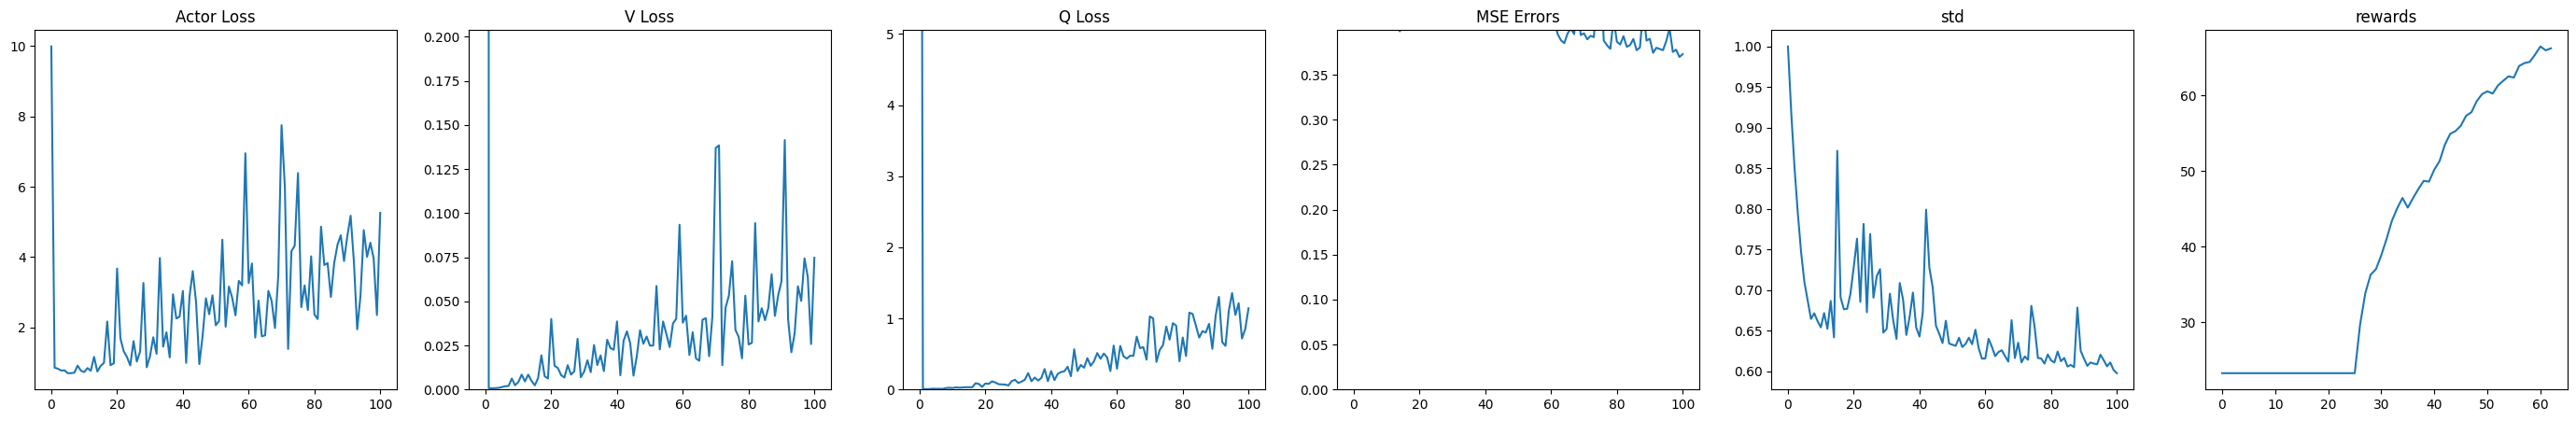

  4%|▎         | 37000/1000000 [05:38<2:26:56, 109.23it/s]


KeyboardInterrupt: 

In [124]:
config = {
    'expectile': 0.9,
    'temperature': 10.0,
    'discount': 0.99,
    'tau': 0.005,
    
    'bc_coefficient': 0.01
}

iql_batch_size = 1024


for timestep in tqdm(range(1000000)):
    
    batch = get_iql_training_data(
        batch_size=iql_batch_size, 
    )

    
        
    # with torch.no_grad():
        
        # target_q1, target_q2 = iql_agent.get_target_critic(batch['states'], batch['actions'])
        # target_q1, target_q2 = target_q1.detach(), target_q2.detach()
        # target_q = torch.minimum(target_q1, target_q2)
        # next_v = iql_agent.get_value(batch['next_states']).detach()
    
    
    # Value Loss: Update V towards expectile of min(q1, q2).
    
    v = iql_agent.get_value(batch['states'])
    
    q1, q2 = iql_agent.get_critic(batch['states'], batch['actions'])
    q = torch.minimum(q1, q2).detach()
    
    adv = q - v
    v_loss = expectile_loss(adv, config['expectile'])
    v_loss = v_loss.mean()

    iql_agent.value.zero_grad(set_to_none=True)
    v_loss.backward()
    iql_agent.value_optim.step()
    

    # Critic Loss. Update Q = r #############################
    
    next_v = iql_agent.get_target_value(batch['states']).detach()
    
    targets = batch['rewards'] + config['discount'] * batch['masks'] * next_v

    q1, q2 = iql_agent.get_critic(batch['states'], batch['actions'])
    q_loss = ((q1 - targets).pow(2).mean() + (q2 - targets).pow(2).mean()) / 2
    
    iql_agent.critic.zero_grad(set_to_none=True)
    q_loss.backward()
    iql_agent.critic_optim.step()
    
    

    # if timestep % 10 == 0:
    update_target_critic(iql_agent.value, iql_agent.target_value, config['tau'])

    value_loss = v_loss + q_loss
    value_info = {
        'v_loss': v_loss,
        'q_loss': q_loss,
        'v': v.mean(),
        'q': torch.minimum(q1, q2).mean(),
    }


    # Actor Loss ############################################

    EPOLICY_EXTRACTION_METHON = 'awr' # awr |  ddpg 
    
    if EPOLICY_EXTRACTION_METHON == 'awr':
        v = iql_agent.get_value(batch['states'])
        q1, q2 = iql_agent.get_critic(batch['states'], batch['actions'])
        q = torch.minimum(q1, q2)
        adv = q - v
        
        actions = batch['actions']
        exp_a = torch.exp(adv.detach() * config['temperature']).clamp(max=100)
        
        dist = iql_agent.get_actor(batch['states'])
        log_probs = dist.log_prob(actions)
        actor_loss = -(exp_a * log_probs).mean()
        
    elif EPOLICY_EXTRACTION_METHON == 'ddpg':
        dist = iql_agent.get_actor(batch['states'])
        normalized_actions = torch.tanh(dist.loc)
        q1, q2 = iql_agent.get_critic(batch['states'], batch['actions'])
        q = (q1 + q2) / 2
        q_loss = -q.mean()
        log_probs = dist.log_prob(batch['actions'])
        bc_loss = -((config['bc_coefficient'] * log_probs)).mean()
        
        actor_loss = ((q_loss + bc_loss)).mean()
    
    
    iql_agent.actor.zero_grad(set_to_none=True)
    actor_loss.backward()
    iql_agent.actor_optim.step()
    iql_agent.actor_lr_schedule.step()
    
    
    
    
    std = dist.stddev.mean()
    mse_error = ((dist.loc - batch['actions'])**2).mean()
    
    actor_info = {
        'actor_loss': actor_loss,
        'std': std,
        'adv': adv.mean(),
        'mse_error': mse_error,
    }
    
    
    ########################################################################################
    

    
    
    
    actor_losses.append(actor_loss.item())
    v_losses.append(v_loss.item())
    q_losses.append(q_loss.item())
    mse_errors.append(mse_error.item())
    stds.append(std.item())
    
    # break
    # continue

    if timestep % 1000 == 0:
        
        produced_trajectory, produced_trajectory_physics = run_test(iql_agent, num_evals=5)
        r = reward_function(torch.tensor(produced_trajectory))
        r_mean = r.sum(dim=1).mean().item()
        r_std = r.sum(dim=1).std().item()
        rewards.append(r_mean)
        
        clear_output(True)
        fig, axs = plt.subplots(1, 6, figsize=(35, 5))
        
        axs[0].plot(smooth_and_downsample(actor_losses))
        axs[1].set_ylim(0,max(actor_losses[-100:]))
        axs[0].set_title("Actor Loss")
        
        axs[1].plot(smooth_and_downsample(v_losses))
        axs[1].set_ylim(0,max(v_losses[-100:]))
        axs[1].set_title("V Loss")
        
        axs[2].plot(smooth_and_downsample(q_losses))
        axs[2].set_ylim(0,max(q_losses[-100:]))
        axs[2].set_title("Q Loss")
        
        axs[3].plot(smooth_and_downsample(mse_errors))
        axs[3].set_ylim(0,max(mse_errors[-100:]))
        axs[3].set_title("MSE Errors")
        
        axs[4].plot(smooth_and_downsample(stds))
        axs[4].set_title("std")
        
        axs[5].plot(smooth_and_downsample(rewards))
        axs[5].set_title("rewards")
        
        plt.show()
        
    # break

In [119]:
print(list(iql_agent.actor.model.parameters())[0][0, :5])

tensor([-0.0509,  0.1271, -0.1367,  0.0626, -0.2376], device='cuda:0',
       grad_fn=<SliceBackward0>)


In [121]:
def timestep2obs(timestep):
    obs = np.concatenate([v if len(v.shape) != 0 else v.reshape(-1) for k, v in timestep.observation.items()])
    return obs

def run_test(iql_agent, num_evals):


    produced_trajectories = []
    produced_trajectories_physics = []
    rewards = []
    
    for _ in range(num_evals):
        
            
            
        timestep = env.reset()        
        state = timestep2obs(timestep)
        # state = normalize_dataset_coords(state)
    
        produced_trajectory = []   
        produced_trajectory_physics = [] 


        for step in tqdm(range(1000)):
            
            with torch.no_grad():
                tensor_state = torch.tensor(state).reshape(1, -1).to(device).float()
                                
                dist = iql_agent.get_actor(tensor_state)
                action = dist.loc.cpu()
                action = np.array(action[0]).clip(-1, 1)

            timestep = env.step(action)
            
            # print(timestep.reward)
            rewards.append(timestep.reward)
            
            next_state = timestep2obs(timestep)
            # state = normalize_dataset_coords(next_state)
            state = next_state
            
            # break
        
            physics = env.physics.get_state()
            produced_trajectory_physics.append(physics)
            
            ENV_NAME = 'walker'
            if ENV_NAME == 'walker':
                horizontal_velocity = env.physics.horizontal_velocity()
                torso_upright = env.physics.torso_upright()
                torso_height = env.physics.torso_height()
                aux = np.array([horizontal_velocity, torso_upright, torso_height])

            elif ENV_NAME == 'cheetah':
                horizontal_velocity = env.physics.speed()
                aux = np.array([horizontal_velocity])
            
            observation_aux = np.concatenate([state, aux])
            
            produced_trajectory.append(observation_aux)
            
            
        produced_trajectory = np.stack(produced_trajectory)
        produced_trajectory_physics = np.stack(produced_trajectory_physics)
                
        produced_trajectories.append(produced_trajectory)
        produced_trajectories_physics.append(produced_trajectory_physics)
        
    
    produced_trajectories = np.stack(produced_trajectories)
    produced_trajectories_physics = np.stack(produced_trajectories_physics)
    

    return produced_trajectories, produced_trajectories_physics



In [30]:
produced_trajectory, produced_trajectory_physics, rewards_ = run_test(iql_agent, 1)
rewards_ = np.array(rewards_)

100%|██████████| 1000/1000 [00:00<00:00, 2415.60it/s]


In [34]:
(rewards_[:500] == r[0, :500].numpy()).all()

True

In [33]:
r = reward_function(torch.tensor(produced_trajectory))
r

/tmp/ipykernel_10520/1924726322.py:45: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(rew[..., 0])


tensor([[0.1621, 0.1620, 0.1616, 0.1608, 0.1593, 0.1564, 0.1514, 0.1426, 0.1293,
         0.1116, 0.0916, 0.0714, 0.0575, 0.0447, 0.0361, 0.0320, 0.0293, 0.0268,
         0.0197, 0.0151, 0.0150, 0.0144, 0.0124, 0.0107, 0.0103, 0.0083, 0.0071,
         0.0065, 0.0060, 0.0055, 0.0052, 0.0050, 0.0048, 0.0046, 0.0045, 0.0044,
         0.0043, 0.0043, 0.0043, 0.0044, 0.0045, 0.0046, 0.0047, 0.0048, 0.0050,
         0.0051, 0.0053, 0.0055, 0.0058, 0.0059, 0.0064, 0.0071, 0.0081, 0.0094,
         0.0110, 0.0131, 0.0149, 0.0165, 0.0181, 0.0199, 0.0160, 0.0139, 0.0135,
         0.0131, 0.0131, 0.0135, 0.0143, 0.0133, 0.0129, 0.0130, 0.0131, 0.0129,
         0.0129, 0.0128, 0.0127, 0.0126, 0.0125, 0.0125, 0.0124, 0.0123, 0.0123,
         0.0123, 0.0123, 0.0123, 0.0123, 0.0123, 0.0123, 0.0123, 0.0123, 0.0123,
         0.0123, 0.0123, 0.0121, 0.0122, 0.0122, 0.0122, 0.0122, 0.0123, 0.0123,
         0.0122, 0.0122, 0.0122, 0.0121, 0.0124, 0.0129, 0.0129, 0.0123, 0.0123,
         0.0123, 0.0123, 0.0

In [70]:
env.reset()

# env_r = []

for i in range(999):
    with env.physics.reset_context():
        # env.physics.set_state(produced_trajectory_physics[3, i])
        env.physics.set_state(dataset['physics'][10, i])
    
    res = env.step(dataset['actions'][10, i])
    # print(res.reward)
    
    # print(env.physics.get_state())
    # print(dataset['physics'][10, i+1])
    print(env._task.get_reward(env.physics))
    
    print(
        reward_function(torch.tensor(dataset['observations'][10, i])).item(),
        reward_function(torch.tensor(dataset['observations'][10, i+1])).item()
    )
    
    # print()
    # break
    # env_r.append(env._task.get_reward(env.physics))

0.13488296357482984
0.1310559854455405 0.13733660676541143
0.12617171262830987
0.13733660676541143 0.12635915562154823
0.12693470559798653
0.12635915562154823 0.12628237668874795
0.1264742820272941
0.12628237668874795 0.12628232273989562
0.12610982289680625
0.12628232273989562 0.1264985532297172
0.1217965747428697
0.1264985532297172 0.12222251667304147
0.10859003466584584
0.12222251667304147 0.10958126663070349
0.09743305991717632
0.10958126663070349 0.09897908585035096
0.06736798673775493
0.09897908585035096 0.0664145894998377
0.04541537521786571
0.0664145894998377 0.04507529202176239
0.03208023270978578
0.04507529202176239 0.031339648015863836
0.030972863844094086
0.031339648015863836 0.030880339308621635
0.03225897673476889
0.030880339308621635 0.03263175168304963
0.020400198265539012
0.03263175168304963 0.020217842035223806
0.010575227068347397
0.020217842035223806 0.009723446597379714
0.002994801102824261
0.009723446597379714 0.0029388908562728543
0.0022884366563919955
0.002938890

/tmp/ipykernel_10520/1924726322.py:45: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(rew[..., 0])


0.04318634624620469 0.04440247122790569
0.04889267910589327
0.04440247122790569 0.05172432561907189
0.05236756255212171
0.05172432561907189 0.05248353543236956
0.05174593558232365
0.05248353543236956 0.051672017034225415
0.04962848209495124
0.051672017034225415 0.05020094744697159
0.04620873482883108
0.05020094744697159 0.04568155118966421
0.04364067572631238
0.04568155118966421 0.043084209340229655
0.04313023739961327
0.043084209340229655 0.044056512845198174
0.04310995263281517
0.044056512845198174 0.04583934150610298
0.044771071659295246
0.04583934150610298 0.04453207127561831
0.045562343654772186
0.04453207127561831 0.04306064367328191
0.04308835160033203
0.04306064367328191 0.04308237220206132
0.04310199698511574
0.04308237220206132 0.043125370278948076
0.04317982288766566
0.043125370278948076 0.04318073296836814
0.04317101860938951
0.04318073296836814 0.04318325863531209
0.04313759619572304
0.04318325863531209 0.04312573239637759
0.04297431584740228
0.04312573239637759 0.04299714

In [64]:
dataset['observations']

array([[[ 8.67139578e-01, -4.98065233e-01, -1.09925441e-01, ...,
          3.84628195e-04,  8.64361769e-01,  1.29629751e+00],
        [ 8.64361763e-01, -5.02870500e-01, -1.18322037e-01, ...,
         -4.82988542e-03,  8.42667925e-01,  1.28615948e+00],
        [ 8.42667937e-01, -5.38433611e-01, -1.28325030e-01, ...,
         -1.32586184e-03,  8.14741790e-01,  1.26885305e+00],
        ...,
        [-1.48045048e-01, -9.88980591e-01, -9.17045295e-01, ...,
          1.38125259e-01, -1.31789595e-01,  1.10237713e-01],
        [-1.31789595e-01, -9.91277695e-01, -9.07137394e-01, ...,
          1.61953401e-01, -1.09740660e-01,  1.01315314e-01],
        [-1.09740660e-01, -9.93960261e-01, -9.01782095e-01, ...,
          7.39060984e-02, -8.57812515e-02,  9.50548675e-02]],

       [[ 5.64993799e-01, -8.25095117e-01,  1.18226588e-01, ...,
         -1.93766555e-02,  6.28313937e-01,  1.29626440e+00],
        [ 6.28313959e-01, -7.77959883e-01,  5.32269403e-02, ...,
         -3.61467516e-02,  7.56222330e

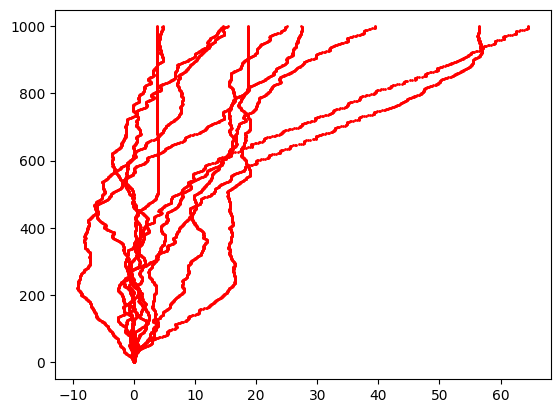

In [ ]:
plt.scatter(
    produced_trajectory_physics[..., 1],
    torch.arange(1000).unsqueeze(1).repeat(1, 10).T,
    c='red', s=1
)

/tmp/ipykernel_29818/554658695.py:45: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(rew[..., 0])


(175.8638460430809, 48.71512075182927)